# 🎮 Experiment 9: K Means Clustering on Video Game Sales

*Date: 02/04/2026*

---




## 🎯 Aim  

To perform **unsupervised clustering** on the Video Game Sales dataset using the **K-Means algorithm**, and determine the optimal number of clusters using **Elbow Method** and **Silhouette Score**.

---

## 📘 Theory  

### 🔹 What is Clustering?  
Clustering is an unsupervised learning technique used to group similar data points based on feature similarity.

---

### 🔹 K-Means Algorithm  

K-Means divides the dataset into **K clusters**, where each data point belongs to the cluster with the nearest centroid.

---

### 🔹 Objective Function  

The goal is to minimize Within-Cluster Sum of Squares (WCSS):

\[
J = \sum_{j=1}^{k} \sum_{i=1}^{n} ||x_i^{(j)} - c_j||^2
\]

---

### 🔹 Steps of K-Means  

1. Initialize K centroids randomly  
2. Assign data points to nearest centroid  
3. Recalculate centroids  
4. Repeat until convergence  

---

### 🔹 Elbow Method  

- Used to find optimal number of clusters  
- Plot K vs WCSS  
- The “elbow point” indicates best K  

---

### 🔹 Silhouette Score  

- Measures cluster quality  
- Range: -1 to +1  
- Higher = better separation  

---

## ⚙️ Step 1: Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

## 📂 Step 2: Upload Dataset

In [ ]:
uploaded = files.upload()

Saving vgsales.csv to vgsales (1).csv


## 📊 Step 3: Load Dataset

In [ ]:
df = pd.read_csv("vgsales.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 🧹 Step 4: Data Preprocessing  

- Remove missing values  
- Select important features  
- Normalize data for clustering  

In [ ]:
df = df.dropna()

features = ['NA_Sales','EU_Sales','JP_Sales','Other_Sales']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing Done ✅")

Preprocessing Done ✅


## 📉 Step 5: Finding Optimal Number of Clusters  

Using:  
✔ Elbow Method  
✔ Silhouette Score  

In [ ]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

## 📊 Step 6: Visualization for Optimal K

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


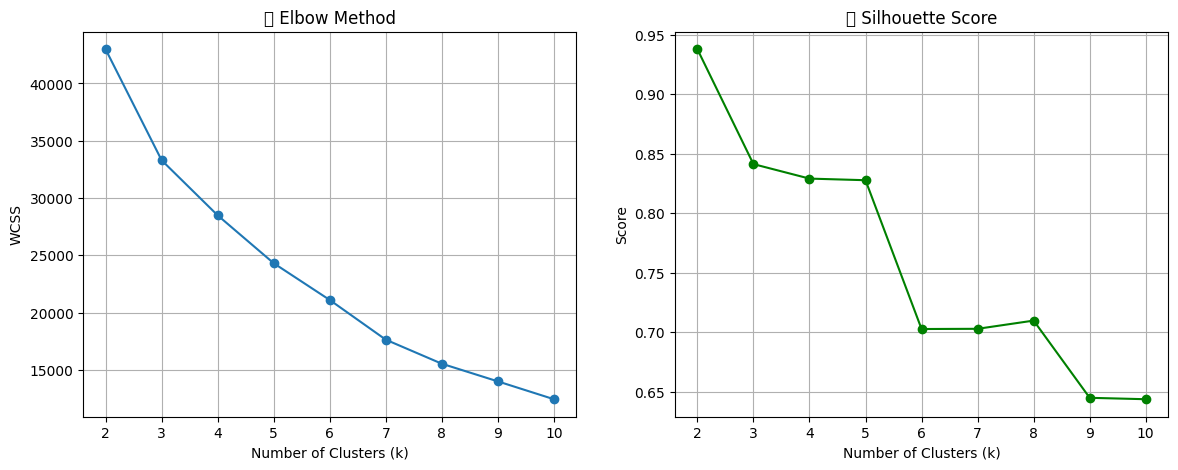

In [ ]:
plt.figure(figsize=(14,5))

# Elbow Method
plt.subplot(1,2,1)
plt.plot(k_range, wcss, marker='o')
plt.title("📉 Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)

# Silhouette Score
plt.subplot(1,2,2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title("📊 Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

plt.show()

## ⚙️ Step 7: Apply K-Means Clustering  

Based on analysis:  
👉 **K = 3**

In [ ]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

centers = kmeans.cluster_centers_

print("Clustering Completed ✅")

Clustering Completed ✅


## 📊 Step 8: Model Evaluation

In [ ]:
silhouette_avg = silhouette_score(X_scaled, labels)

print("Silhouette Score:", round(silhouette_avg, 4))
print("WCSS:", round(kmeans.inertia_, 4))

Silhouette Score: 0.8413
WCSS: 33300.1656


## 📉 Step 9: Visualization using PCA

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


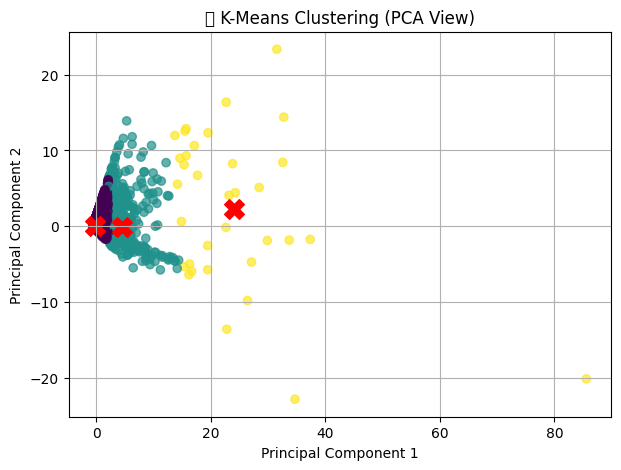

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

centers_pca = pca.transform(centers)

plt.figure(figsize=(7,5))

plt.scatter(X_pca[:,0], X_pca[:,1],
            c=labels, cmap='viridis', alpha=0.7)

plt.scatter(centers_pca[:,0], centers_pca[:,1],
            c='red', marker='X', s=200)

plt.title("📊 K-Means Clustering (PCA View)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

## 📌 Result  

- Data successfully grouped into **3 clusters**  
- Elbow and Silhouette methods helped identify optimal K  
- PCA visualization shows clear cluster separation  

---

## 🧠 Conclusion  

K-Means clustering effectively grouped the dataset based on regional sales patterns. Feature scaling and proper selection of K improved clustering quality and interpretability.

---

## ✅ Experiment Completed Successfully